# Regression Analysis 

## Predict number of vehicles

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../data/Engineered_Traffic_Data.csv", low_memory=False)

In [15]:
REG_FEATURES = ["weather_conditions_enc", "light_conditions",
                "road_surface_conditions_enc", "junction_detail_enc",
                "junction_control_enc", "speed_limit", "urban_or_rural_area_enc",
                "day_of_week", "hour", "is_weekend"]

X_reg = df[REG_FEATURES]
y_reg = df["number_of_vehicles"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg,
    test_size=0.25, random_state=42)

regressors = {
    "Linear":        LinearRegression(),
    "Ridge":         Ridge(alpha=1.0),
    "Lasso":         Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, reg in regressors.items():
    reg.fit(Xr_train, yr_train)
    y_pred = reg.predict(Xr_test)
    mae  = mean_absolute_error(yr_test, y_pred)
    rmse = np.sqrt(mean_squared_error(yr_test, y_pred))
    r2   = r2_score(yr_test, y_pred)
    # 5-fold CV R²
    cv_r2 = cross_val_score(reg, X_reg, y_reg, cv=5, scoring="r2").mean()
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}, CV-R²={cv_r2:.3f}")


Linear: MAE=0.537, RMSE=0.632, R²=0.036, CV-R²=0.031
Ridge: MAE=0.537, RMSE=0.632, R²=0.036, CV-R²=0.031
Lasso: MAE=0.555, RMSE=0.640, R²=0.011, CV-R²=0.008
Random Forest: MAE=0.545, RMSE=0.687, R²=-0.141, CV-R²=-0.143


## Temporal Trend Regression

Now im going to predict the collision count per year

Trend slope: -2.3 collisions/year
Predicted collisions 2025-2030: [54 44 34 23 12  1]


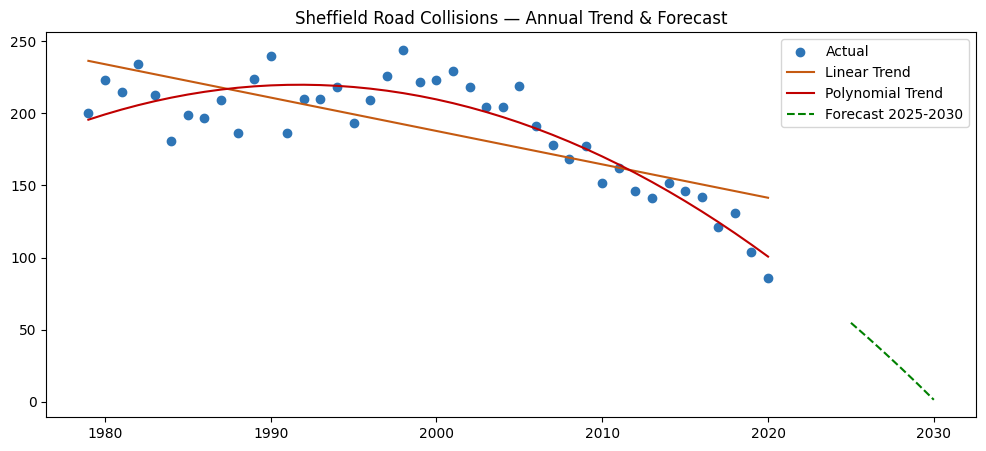

In [16]:
yearly = df.groupby("collision_year").size().reset_index(name="collision_count")

X_time = yearly[["collision_year"]]
y_time = yearly["collision_count"]

# Linear trend
lr_time = LinearRegression()
lr_time.fit(X_time, y_time)
print(f"Trend slope: {lr_time.coef_[0]:.1f} collisions/year")

# Polynomial trend (degree 2 captures non-linear patterns)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_time)
lr_poly = LinearRegression()
lr_poly.fit(X_poly, y_time)

# Predict future years (2025–2030)
future_years = pd.DataFrame({"collision_year": range(2025, 2031)})
future_pred = lr_poly.predict(poly.transform(future_years))
print("Predicted collisions 2025-2030:", future_pred.astype(int))

# Plot trend
plt.figure(figsize=(12, 5))
plt.scatter(X_time, y_time, label="Actual", color="#2E75B6")
plt.plot(X_time, lr_time.predict(X_time), label="Linear Trend", color="#C55A11")
plt.plot(X_time, lr_poly.predict(X_poly), label="Polynomial Trend", color="#C00000")
plt.plot(future_years, future_pred, "--", label="Forecast 2025-2030", color="green")
plt.title("Sheffield Road Collisions — Annual Trend & Forecast")
plt.legend()
plt.savefig("../results/C3-trend_regression.png", bbox_inches="tight")


## Temporal Trend Analysis

The scatter plot reveals that the historical collision counts are non-linear. They peaked heavily in the 1990s before experiencing a sharp decline from the early 2000s onwards. The linear trend fails to capture this as it underpredicts the peak and overpredicts the recent years. The polynomial trend fits the results much more accuractly.

The forecast aggresively predicts from the downward curve that collisions wll drop to almost zero, this shows a weakness with polynomial models as it clearly is unrealistic as its practically impossible for a major city to reach zero collisions.

## Residual Analysis

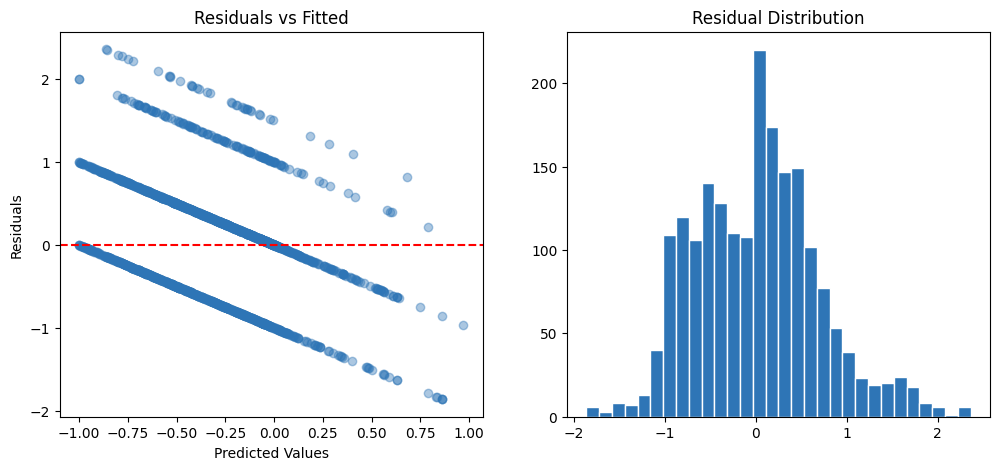

In [17]:
best_reg = RandomForestRegressor(n_estimators=200, random_state=42)
best_reg.fit(Xr_train, yr_train)
y_pred_rf = best_reg.predict(Xr_test)

residuals = yr_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#residuals vs fitted
axes[0].scatter(y_pred_rf, residuals, alpha=0.4, color="#2E75B6")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")
#residual distribution
axes[1].hist(residuals, bins=30, color="#2E75B6", edgecolor="white")
axes[1].set_title("Residual Distribution")
plt.savefig("../results/C3-residuals.png", bbox_inches="tight")


## Residuals vs Fitted Analysis

The model struggles to predict extreme events like a crash with more than 5+ vehicles rather than a standard 2 car collision.

## Residual Distribution Analysis

This indicates that the Random Forest has a systematic bias as its underestimating the number of vehicles envolved.

